# Climate Features Analysis: Weighted vs Simple Mean by Season

This notebook compares climate features using:
1. **Weighted Average** - Aggregated by state production weights
2. **Simple Mean** - Unweighted average across all states
3. **Random State** - Individual state comparison

Analysis is done separately for **planting** and **harvesting** seasons.

## Imports

In [19]:
import sys
import warnings
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.util.path import DATA_DIR
from src.dataset.util.production_by_state import load_production_weights, STATE_ABBREV_TO_NAME

## Settings

In [20]:
# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
FIGSIZE_HIST = (16, 6)
FIGSIZE_TS = (16, 6)

# Crop to analyze
CROP = 'wheat'

# Climate features to analyze
CLIMATE_FEATURES = ['TMAX', 'TMIN', 'AWND']

# Paths
PRODUCTION_DIR = DATA_DIR / 'production_by_state'

# Random seed
random.seed(42)
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load Data

In [21]:
# Load weighted climate data (already aggregated by production weights)
weighted_file = DATA_DIR / 'climate' / f'climate_weekly_weighted_{CROP}.csv'
df_weighted = pd.read_csv(weighted_file)
df_weighted['date'] = pd.to_datetime(df_weighted['date'])

print(f"Weighted {CROP} data shape: {df_weighted.shape}")
print(f"Date range: {df_weighted['date'].min()} to {df_weighted['date'].max()}")
print(f"\nColumns: {df_weighted.columns.tolist()[:20]}...")  # Show first 20 columns
df_weighted.head()

Weighted wheat data shape: (888, 57)
Date range: 2008-12-29 00:00:00 to 2025-12-29 00:00:00

Columns: ['date', 'week_of_year', 'year', 'month', 'is_planting_week', 'is_harvesting_week', 'TMAX', 'TMIN', 'AWND', 'SPI_1m', 'SPI_3m', 'SPI_7d', 'TMAX_zscore', 'TMIN_zscore', 'AWND_zscore', 'TMAX_q3_value_in_planting', 'TMAX_q3_value_in_harvesting', 'TMAX_q4_value_in_planting', 'TMAX_q4_value_in_harvesting', 'TMIN_q3_value_in_planting']...


,date,week_of_year,year,month,is_planting_week,is_harvesting_week,TMAX,TMIN,AWND,SPI_1m,SPI_3m,SPI_7d,TMAX_zscore,TMIN_zscore,AWND_zscore,TMAX_q3_value_in_planting,TMAX_q3_value_in_harvesting,TMAX_q4_value_in_planting,TMAX_q4_value_in_harvesting,TMIN_q3_value_in_planting,TMIN_q3_value_in_harvesting,TMIN_q4_value_in_planting,TMIN_q4_value_in_harvesting,AWND_q3_value_in_planting,AWND_q3_value_in_harvesting,AWND_q4_value_in_planting,AWND_q4_value_in_harvesting,monthly_SPI_1m,seasonal_SPI_1m,monthly_SPI_3m,seasonal_SPI_3m,monthly_SPI_7d,seasonal_SPI_7d,monthly_TMAX_q3_value_in_planting,seasonal_TMAX_q3_value_in_planting,monthly_TMAX_q3_value_in_harvesting,seasonal_TMAX_q3_value_in_harvesting,monthly_TMAX_q4_value_in_planting,seasonal_TMAX_q4_value_in_planting,monthly_TMAX_q4_value_in_harvesting,seasonal_TMAX_q4_value_in_harvesting,monthly_TMIN_q3_value_in_planting,seasonal_TMIN_q3_value_in_planting,monthly_TMIN_q3_value_in_harvesting,seasonal_TMIN_q3_value_in_harvesting,monthly_TMIN_q4_value_in_planting,seasonal_TMIN_q4_value_in_planting,monthly_TMIN_q4_value_in_harvesting,seasonal_TMIN_q4_value_in_harvesting,monthly_AWND_q3_value_in_planting,seasonal_AWND_q3_value_in_planting,monthly_AWND_q3_value_in_harvesting,seasonal_AWND_q3_value_in_harvesting,monthly_AWND_q4_value_in_planting,seasonal_AWND_q4_value_in_planting,monthly_AWND_q4_value_in_harvesting,seasonal_AWND_q4_value_in_harvesting
0,2008-12-29,1,2008,12,0,0,2.733711,-10.144065,4.392906,0.000000,0.0,0.000000,0.298709,-0.341487,1.099360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2009-01-05,2,2009,1,0,0,2.630792,-8.482901,3.887690,0.000000,0.0,-0.144730,-0.003457,-0.117703,-0.351195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.072365,-0.072365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2009-01-12,3,2009,1,0,0,1.503348,-11.544296,4.354387,0.000000,0.0,-0.977229,-0.351867,-0.994717,0.769789,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.373986,-0.373986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2009-01-19,4,2009,1,0,0,3.107813,-9.205357,3.821561,0.000000,0.0,-1.261567,-0.149345,-0.525150,-0.177493,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.595881,-0.595881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2009-01-26,5,2009,1,0,0,1.050910,-10.685157,4.106382,-1.106142,0.0,-0.548105,-0.805491,-0.863574,0.268744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.276535,-0.221228,0.0,0.0,-0.732907,-0.586326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Load state-level NOAA weekly data for simple mean calculation
noaa_weekly_file = DATA_DIR / 'climate' / 'noaa_weekly.csv'
df_noaa = pd.read_csv(noaa_weekly_file)
df_noaa['date'] = pd.to_datetime(df_noaa['date'])

print(f"\nNOAA weekly data shape: {df_noaa.shape}")
print(f"Date range: {df_noaa['date'].min()} to {df_noaa['date'].max()}")
print(f"Number of states: {df_noaa['state'].nunique()}")
df_noaa.head()


NOAA weekly data shape: (94000, 6)
Date range: 1990-01-01 00:00:00 to 2025-12-29 00:00:00
Number of states: 50


,state,date,PRCP,TMAX,TMIN,AWND
0,AK,1990-01-01,NaN,-11.266597,-18.090278,4.023571
1,AK,1990-01-08,NaN,-8.162190,-17.025771,4.218299
2,AK,1990-01-15,NaN,-1.904951,-8.212460,4.729286
3,AK,1990-01-22,NaN,-10.639633,-18.063999,3.094218
4,AK,1990-01-29,NaN,-15.823874,-24.261170,4.513831


In [23]:
# Load production weights
production_weights = load_production_weights(CROP, PRODUCTION_DIR)

print(f"\nProduction weights shape: {production_weights.shape}")
print(f"\nTop 10 states by {CROP} production:")
print(production_weights.sort_values('state_weight', ascending=False).head(10))


Production weights shape: (49, 2)

Top 10 states by wheat production:
           state  state_weight
14        Kansas      0.149011
32  North Dakota      0.129402
34      Oklahoma      0.067442
24       Montana      0.063793
45    Washington      0.061253
25      Nebraska      0.042512
39  South Dakota      0.042490
21     Minnesota      0.041396
41         Texas      0.037786
10         Idaho      0.036192


## Calculate Simple Mean (Unweighted)

In [24]:
# Calculate simple mean across all states
df_noaa['week_of_year'] = df_noaa['date'].dt.isocalendar().week.astype(int)

# Add seasonal flags based on crop
from src.dataset.climate.crop_seasonal import crop_season_flag

flags = df_noaa['week_of_year'].apply(lambda w: crop_season_flag(int(w), CROP))
df_noaa['is_planting_week'] = flags.map(lambda f: f['is_planting_week'])
df_noaa['is_harvesting_week'] = flags.map(lambda f: f['is_harvesting_week'])

# Calculate simple mean by date
df_simple_mean = df_noaa.groupby(['date', 'week_of_year', 'is_planting_week', 'is_harvesting_week'], as_index=False)[CLIMATE_FEATURES].mean()

print(f"Simple mean data shape: {df_simple_mean.shape}")
print(f"Date range: {df_simple_mean['date'].min()} to {df_simple_mean['date'].max()}")
df_simple_mean.head()

Simple mean data shape: (1879, 7)
Date range: 1990-01-01 00:00:00 to 2025-12-29 00:00:00


,date,week_of_year,is_planting_week,is_harvesting_week,TMAX,TMIN,AWND
0,1990-01-01,1,0,0,7.051981,-3.862139,4.209915
1,1990-01-08,2,0,0,8.559069,-2.900961,4.719708
2,1990-01-15,3,0,0,9.050974,-1.562375,3.908892
3,1990-01-22,4,0,0,8.838162,-3.003364,4.712054
4,1990-01-29,5,0,0,8.031889,-3.547308,4.398213


## Select Random State

In [25]:
# Get states with production weights
producing_states = production_weights[production_weights['state_weight'] > 0]['state'].tolist()

# Map state names to abbreviations
name_to_abbrev = {v: k for k, v in STATE_ABBREV_TO_NAME.items()}
producing_state_abbrevs = [name_to_abbrev.get(s, s) for s in producing_states if name_to_abbrev.get(s) in df_noaa['state'].values]

# Select random state
random_state_abbrev = random.choice(producing_state_abbrevs)
random_state_name = STATE_ABBREV_TO_NAME.get(random_state_abbrev, random_state_abbrev)

print(f"Randomly selected state: {random_state_name} ({random_state_abbrev})")
state_weight = production_weights[production_weights['state'] == random_state_name]['state_weight'].values
if len(state_weight) > 0:
    print(f"Production weight: {state_weight[0]:.4f}")

# Filter data for random state
df_random_state = df_noaa[df_noaa['state'] == random_state_abbrev].copy()

print(f"\nRandom state data shape: {df_random_state.shape}")
print(f"Date range: {df_random_state['date'].min()} to {df_random_state['date'].max()}")
df_random_state.head()

Randomly selected state: Tennessee (TN)
Production weight: 0.0076

Random state data shape: (1880, 9)
Date range: 1990-01-01 00:00:00 to 2025-12-29 00:00:00


,state,date,PRCP,TMAX,TMIN,AWND,week_of_year,is_planting_week,is_harvesting_week
40672,TN,1990-01-01,NaN,9.813821,-0.105142,2.316667,1,0,0
40673,TN,1990-01-08,NaN,10.975865,-1.764429,3.988095,2,0,0
40674,TN,1990-01-15,NaN,15.717285,5.324938,3.228571,3,0,0
40675,TN,1990-01-22,NaN,12.986615,0.332786,3.492857,4,0,0
40676,TN,1990-01-29,NaN,15.018292,2.563291,3.064286,5,0,0


## Plot Functions

In [26]:
def plot_weighted_vs_simple_by_season(df_weighted, df_simple, feature, crop, season='planting'):
    """
    Compare weighted average vs simple mean for a specific season.
    """
    season_col = 'is_planting_week' if season == 'planting' else 'is_harvesting_week'
    season_name = 'Planting' if season == 'planting' else 'Harvesting'
    
    # Filter by season
    weighted_season = df_weighted[df_weighted[season_col] == 1]
    simple_season = df_simple[df_simple[season_col] == 1]
    
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_HIST)
    fig.suptitle(f'{crop.upper()} - {feature} ({season_name} Season): Weighted vs Simple Mean', 
                 fontsize=16, fontweight='bold')
    
    # Histogram comparison
    axes[0].hist(weighted_season[feature].dropna(), bins=40, alpha=0.6, color='steelblue', 
                 label='Weighted', edgecolor='black')
    axes[0].hist(simple_season[feature].dropna(), bins=40, alpha=0.6, color='orange', 
                 label='Simple Mean', edgecolor='black')
    axes[0].set_xlabel(feature, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution Comparison', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Time series comparison
    axes[1].plot(weighted_season['date'], weighted_season[feature], 
                 color='steelblue', alpha=0.7, linewidth=1.2, label='Weighted')
    axes[1].plot(simple_season['date'], simple_season[feature], 
                 color='orange', alpha=0.7, linewidth=1.2, label='Simple Mean')
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_ylabel(feature, fontsize=12)
    axes[1].set_title('Time Series Comparison', fontsize=14, fontweight='bold')
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
    
    # Add statistics
    stats_weighted = f"Weighted:\nMean: {weighted_season[feature].mean():.2f}\nStd: {weighted_season[feature].std():.2f}"
    stats_simple = f"Simple:\nMean: {simple_season[feature].mean():.2f}\nStd: {simple_season[feature].std():.2f}"
    axes[0].text(0.02, 0.98, stats_weighted, transform=axes[0].transAxes,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7), fontsize=9)
    axes[0].text(0.98, 0.98, stats_simple, transform=axes[0].transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=9)
    
    plt.tight_layout()
    plt.show()

def plot_random_state_comparison(df_weighted, df_simple, df_state, feature, crop, state_name, season='planting'):
    """
    Compare weighted, simple mean, and random state for a specific season.
    """
    season_col = 'is_planting_week' if season == 'planting' else 'is_harvesting_week'
    season_name = 'Planting' if season == 'planting' else 'Harvesting'
    
    # Filter by season
    weighted_season = df_weighted[df_weighted[season_col] == 1]
    simple_season = df_simple[df_simple[season_col] == 1]
    state_season = df_state[df_state[season_col] == 1]
    
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_TS)
    fig.suptitle(f'{crop.upper()} - {feature} ({season_name} Season): National vs {state_name}', 
                 fontsize=16, fontweight='bold')
    
    # Histogram comparison
    axes[0].hist([weighted_season[feature].dropna(), simple_season[feature].dropna(), state_season[feature].dropna()],
                 bins=30, alpha=0.6, label=['Weighted', 'Simple Mean', state_name], edgecolor='black')
    axes[0].set_xlabel(feature, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution Comparison', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Time series comparison
    axes[1].plot(weighted_season['date'], weighted_season[feature], 
                 color='steelblue', alpha=0.7, linewidth=1.2, label='Weighted')
    axes[1].plot(simple_season['date'], simple_season[feature], 
                 color='orange', alpha=0.7, linewidth=1.2, label='Simple Mean')
    axes[1].plot(state_season['date'], state_season[feature], 
                 color='green', alpha=0.7, linewidth=1.2, label=state_name)
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_ylabel(feature, fontsize=12)
    axes[1].set_title('Time Series Comparison', fontsize=14, fontweight='bold')
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Analysis: Weighted vs Simple Mean

### Planting Season


Analyzing: TMAX - Planting Season


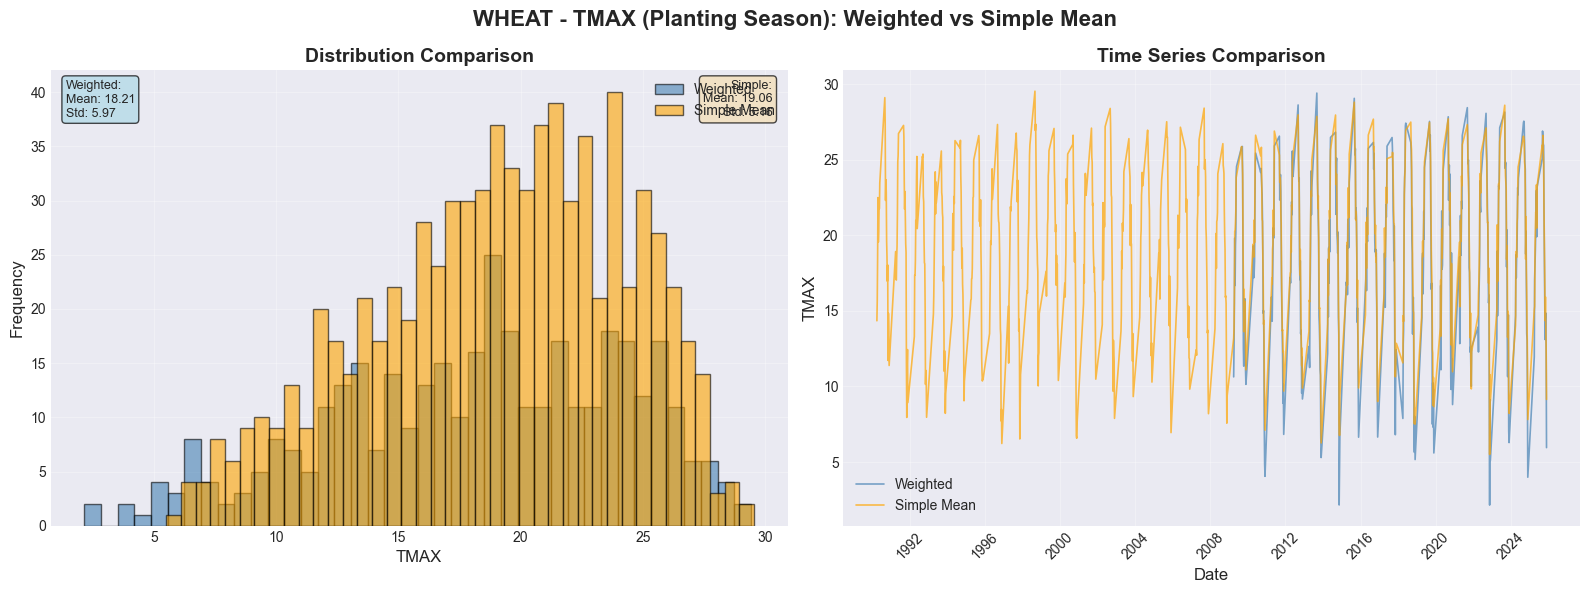


Analyzing: TMIN - Planting Season


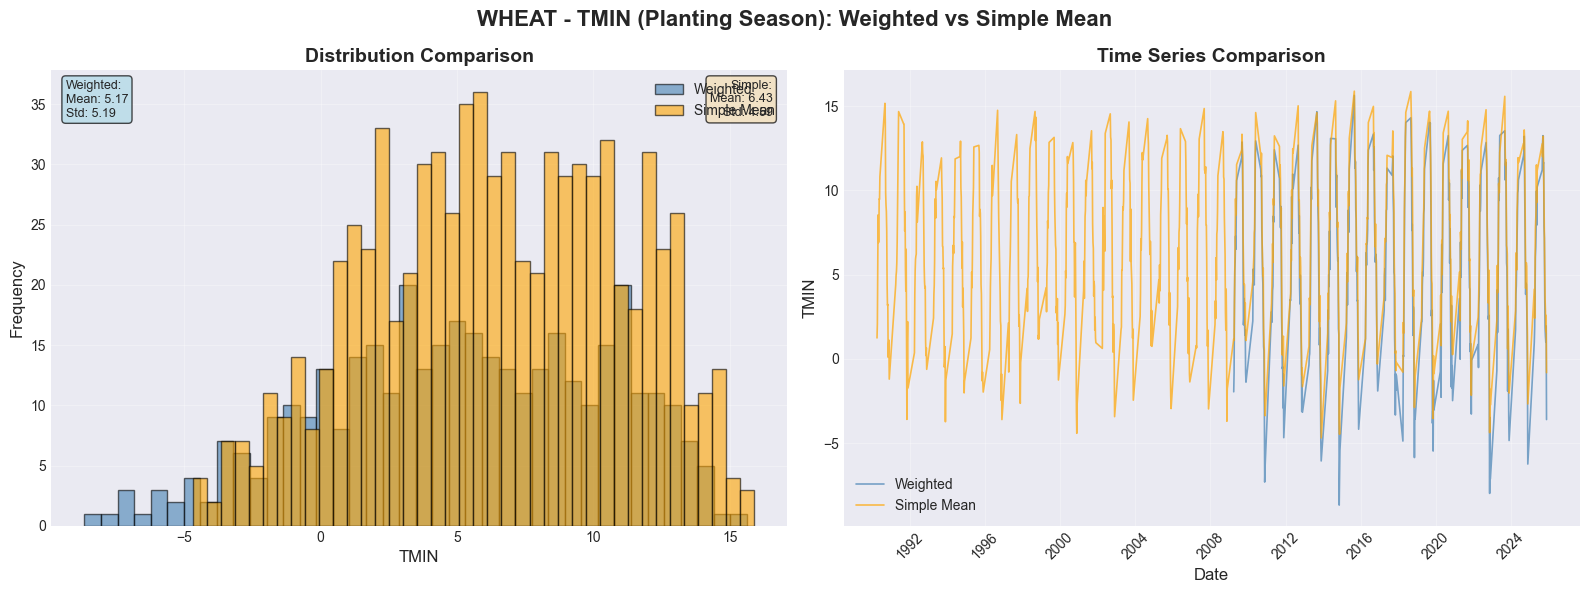


Analyzing: AWND - Planting Season


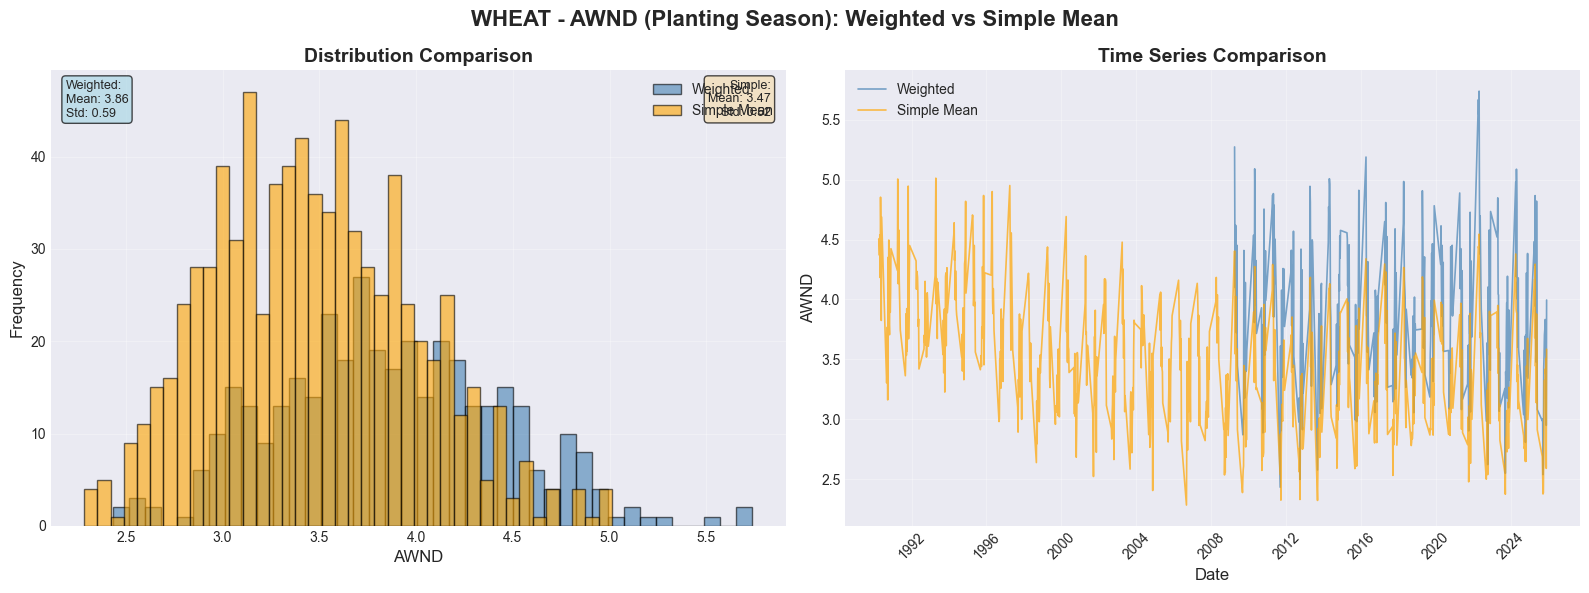

In [14]:
for feature in CLIMATE_FEATURES:
    if feature in df_weighted.columns and feature in df_simple_mean.columns:
        print(f"\n{'='*80}")
        print(f"Analyzing: {feature} - Planting Season")
        print(f"{'='*80}")
        plot_weighted_vs_simple_by_season(df_weighted, df_simple_mean, feature, CROP, season='planting')

### Harvesting Season


Analyzing: TMAX - Harvesting Season


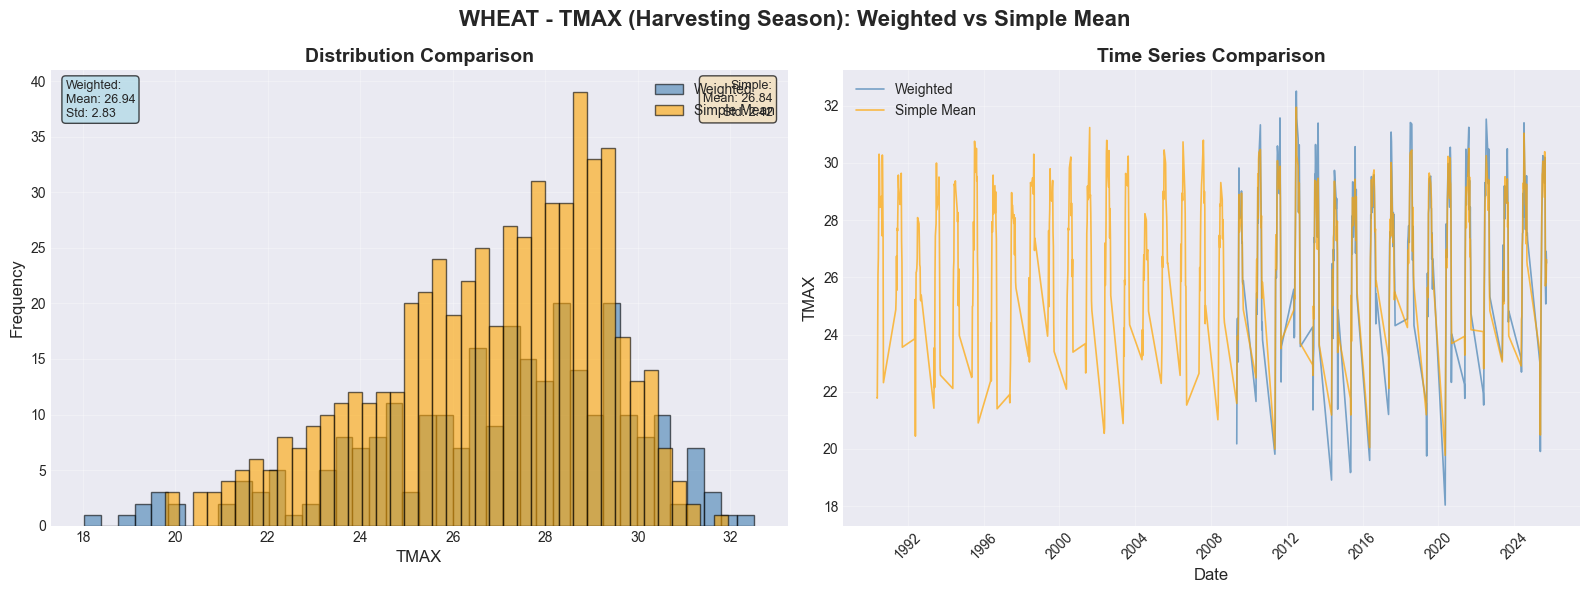


Analyzing: TMIN - Harvesting Season


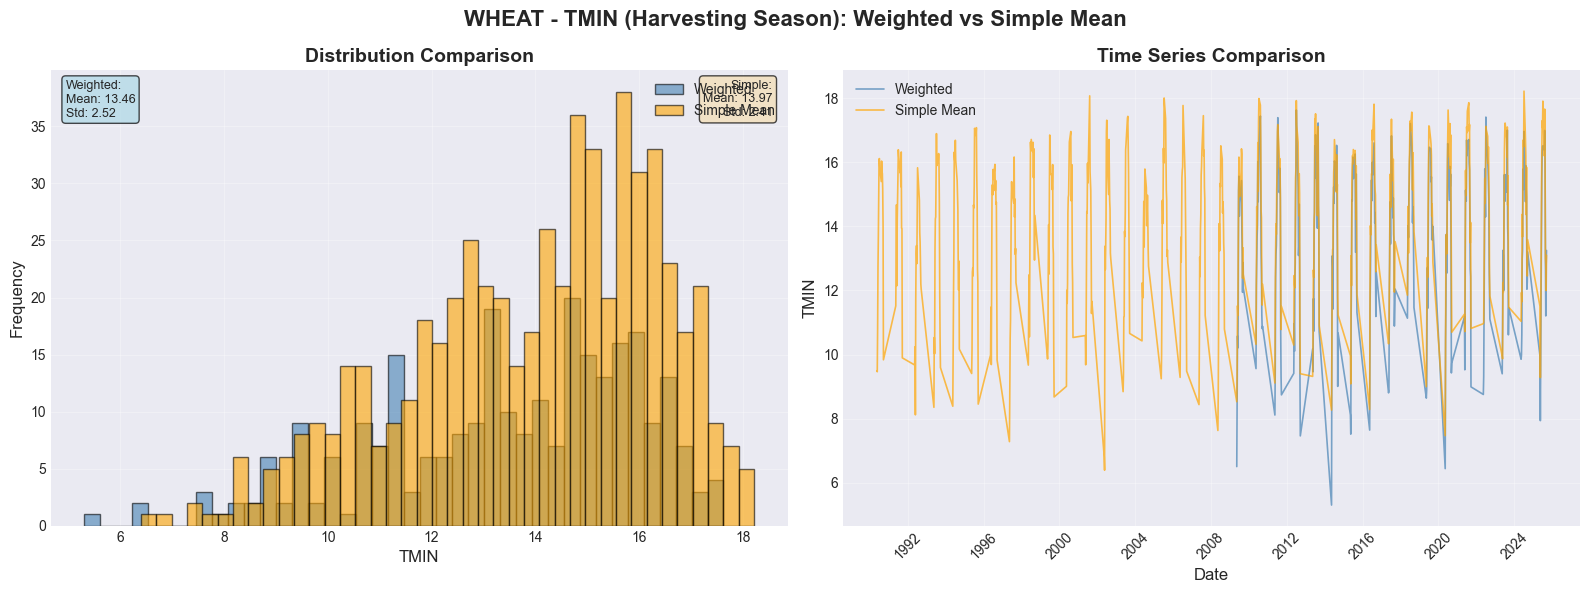


Analyzing: AWND - Harvesting Season


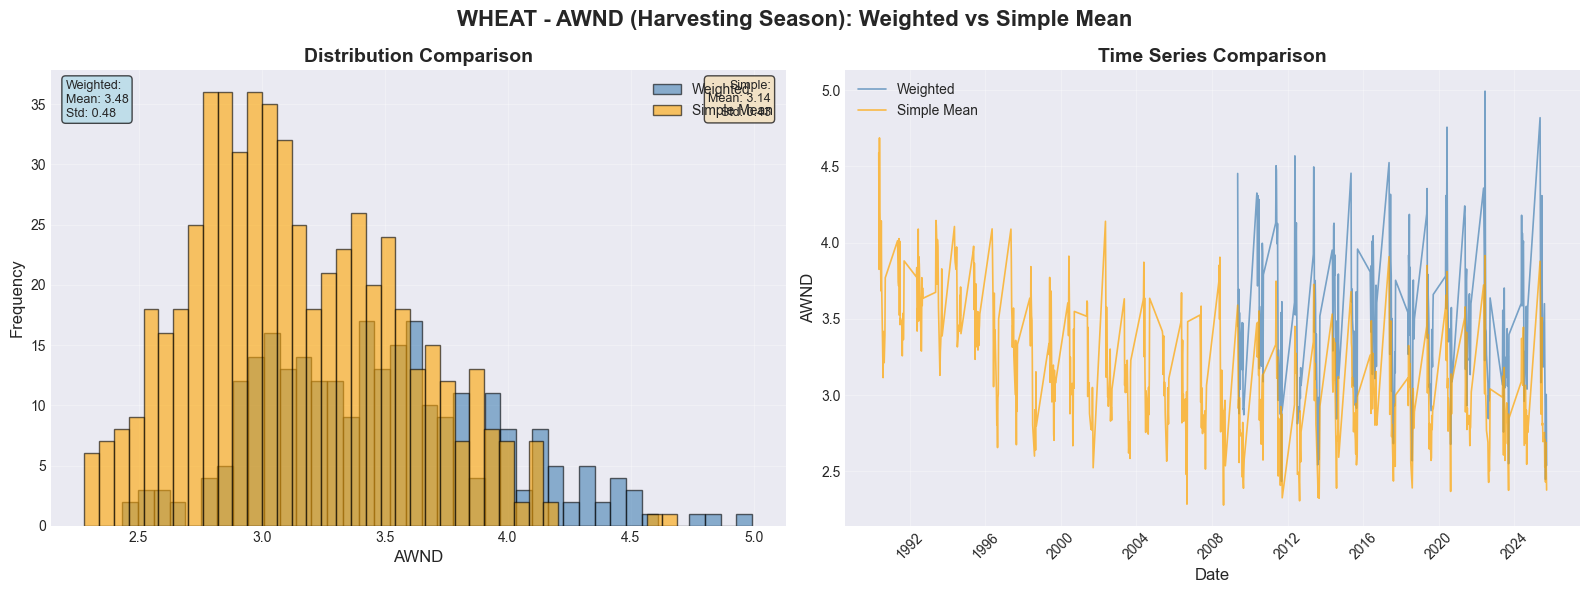

In [15]:
for feature in CLIMATE_FEATURES:
    if feature in df_weighted.columns and feature in df_simple_mean.columns:
        print(f"\n{'='*80}")
        print(f"Analyzing: {feature} - Harvesting Season")
        print(f"{'='*80}")
        plot_weighted_vs_simple_by_season(df_weighted, df_simple_mean, feature, CROP, season='harvesting')

## Analysis: National vs Random State

### Planting Season


Analyzing: TMAX - Planting Season (National vs Tennessee)


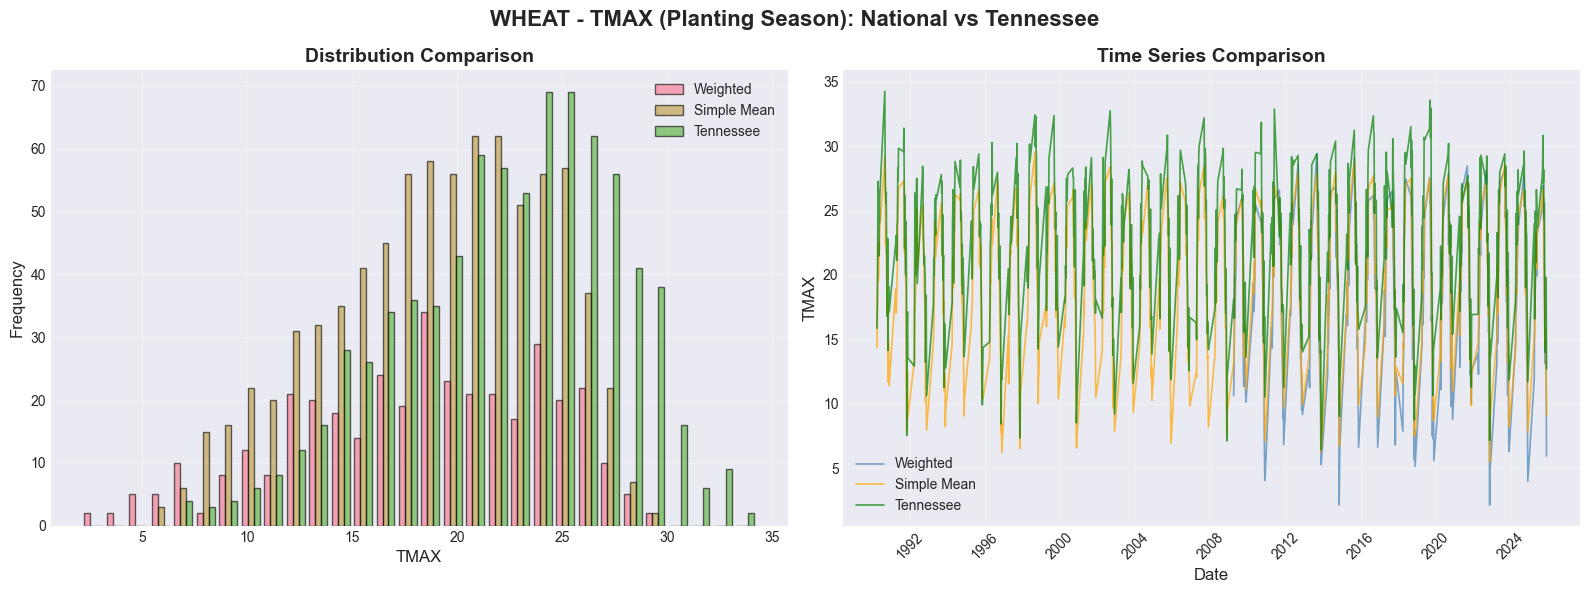


Analyzing: TMIN - Planting Season (National vs Tennessee)


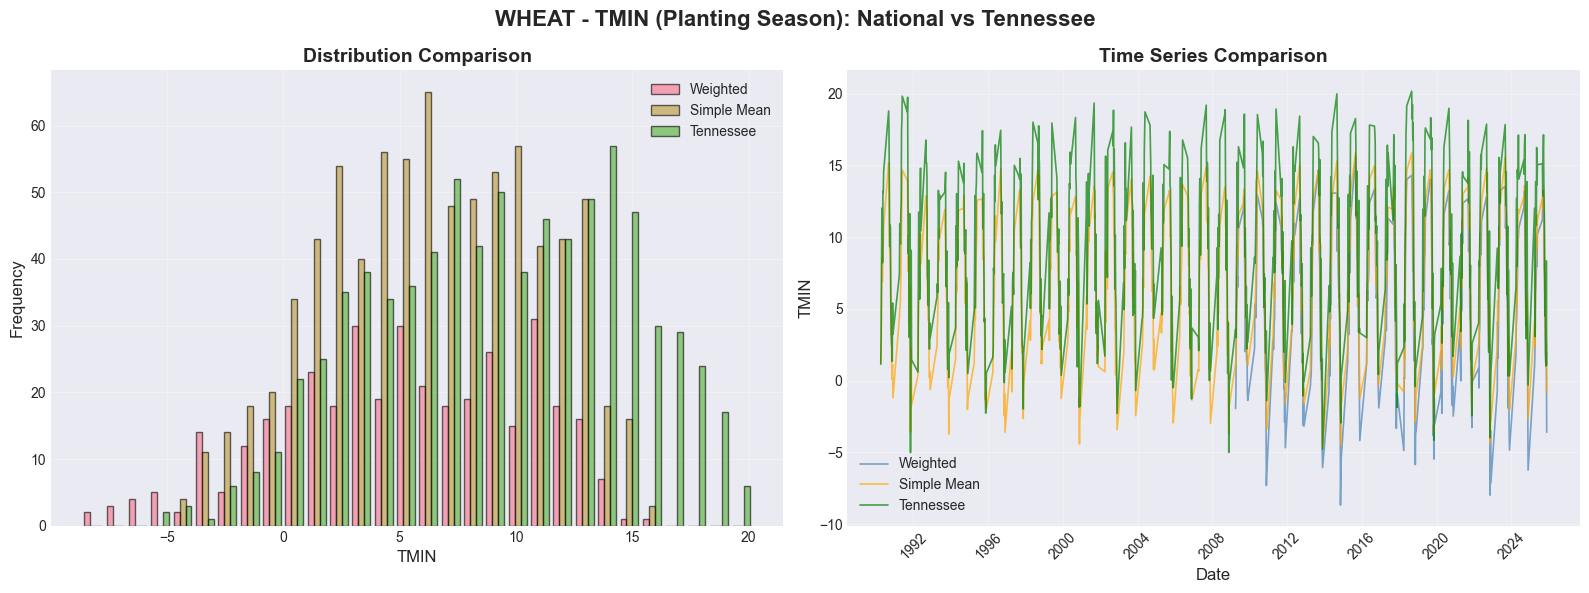


Analyzing: AWND - Planting Season (National vs Tennessee)


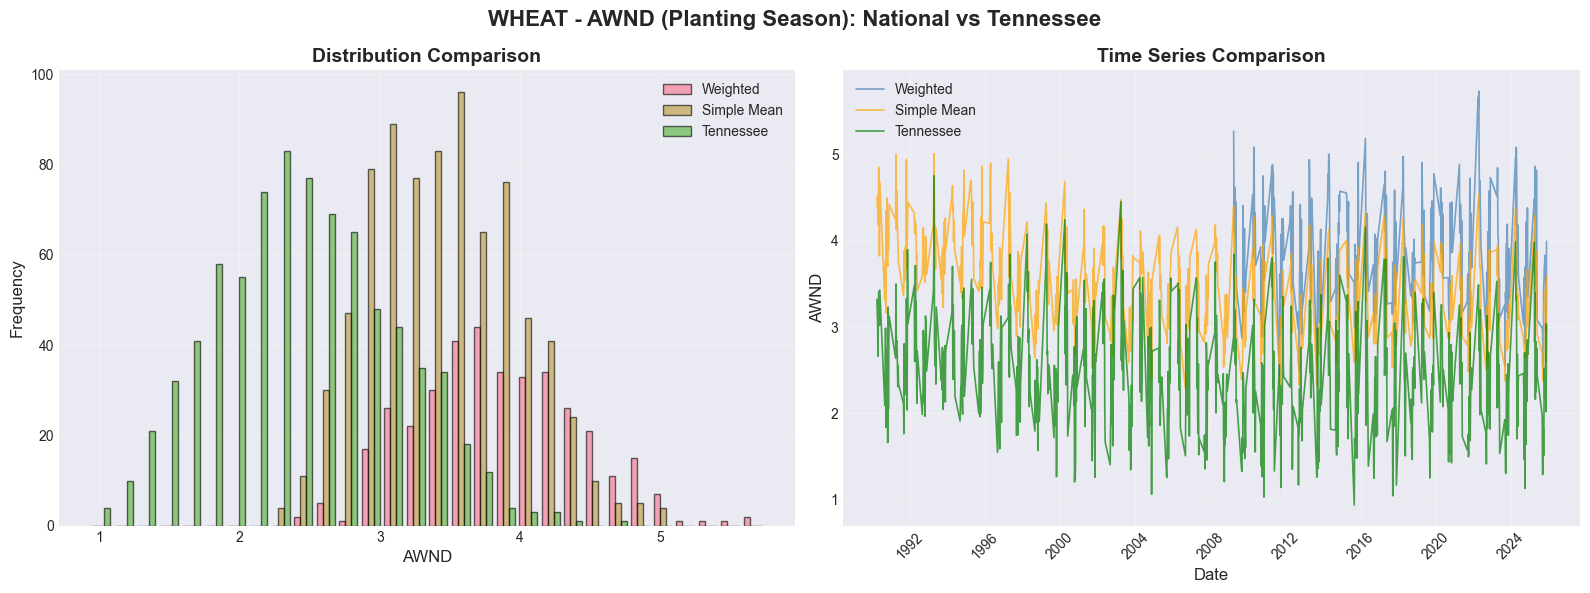

In [16]:
for feature in CLIMATE_FEATURES:
    if feature in df_weighted.columns and feature in df_random_state.columns:
        print(f"\n{'='*80}")
        print(f"Analyzing: {feature} - Planting Season (National vs {random_state_name})")
        print(f"{'='*80}")
        plot_random_state_comparison(df_weighted, df_simple_mean, df_random_state, 
                                     feature, CROP, random_state_name, season='planting')

### Harvesting Season


Analyzing: TMAX - Harvesting Season (National vs Tennessee)


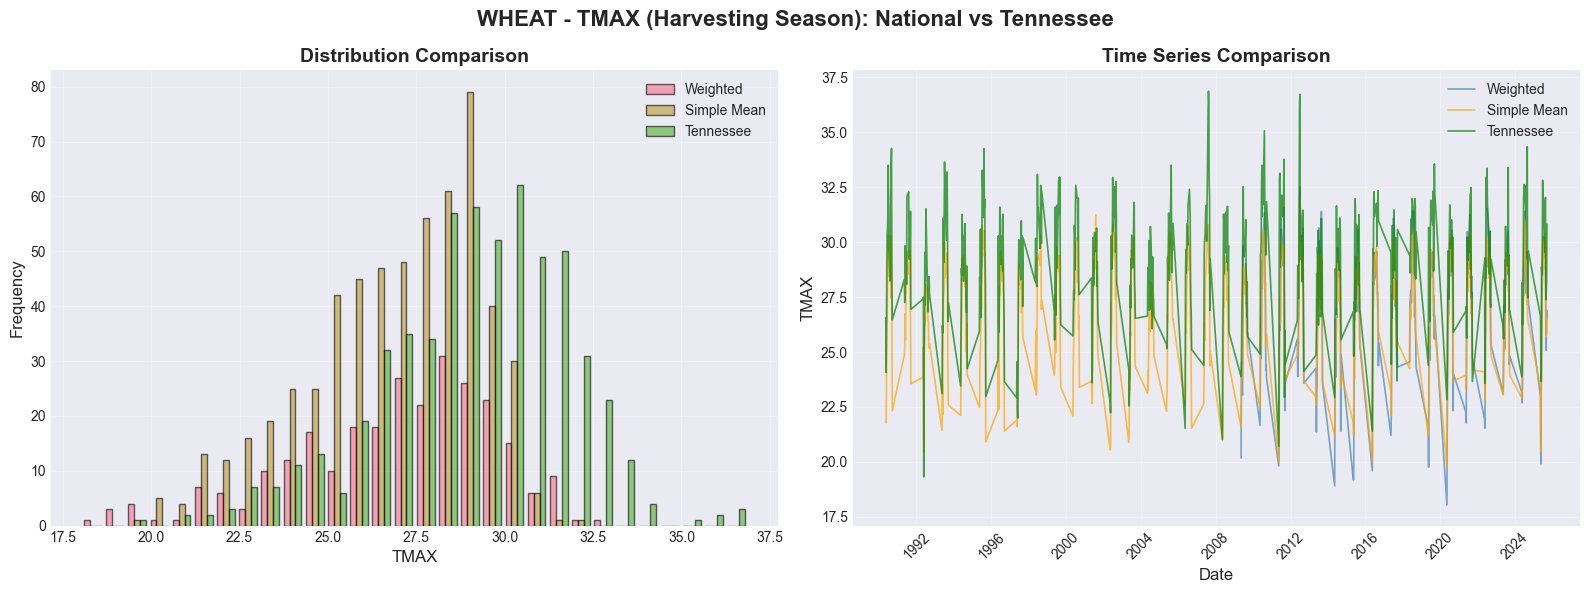


Analyzing: TMIN - Harvesting Season (National vs Tennessee)


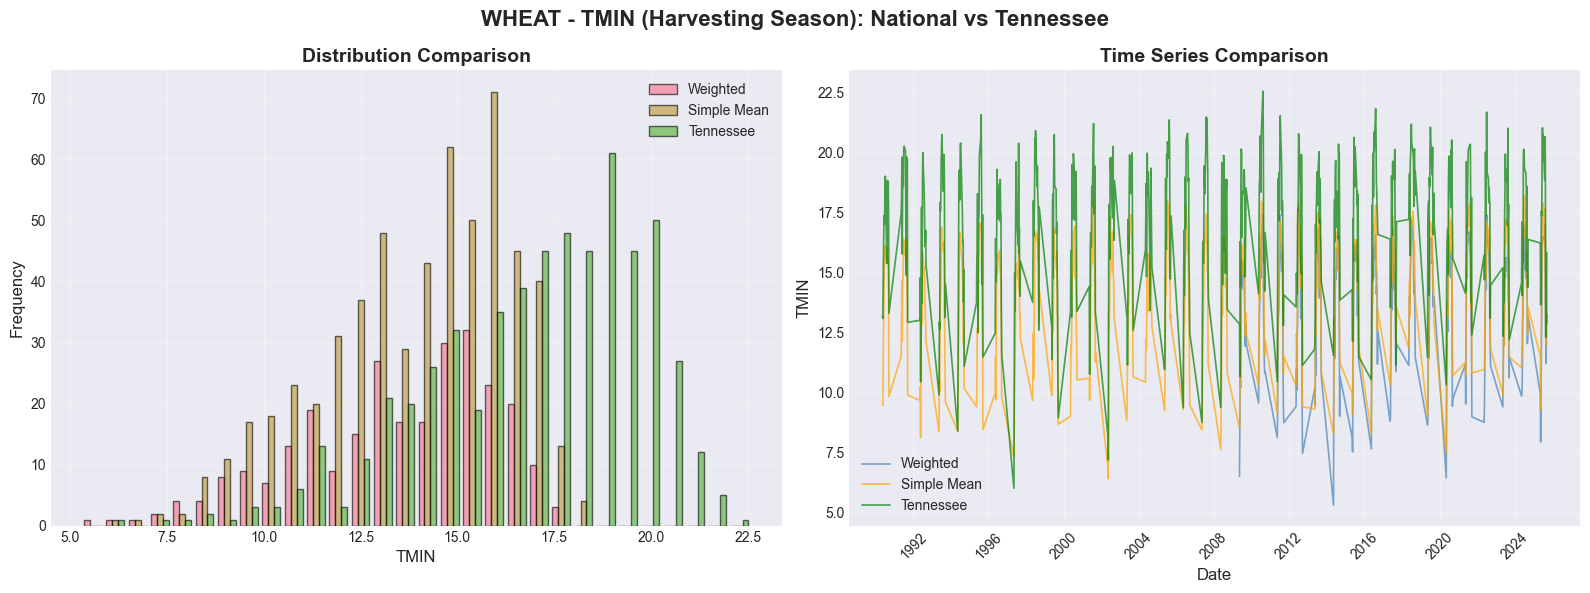


Analyzing: AWND - Harvesting Season (National vs Tennessee)


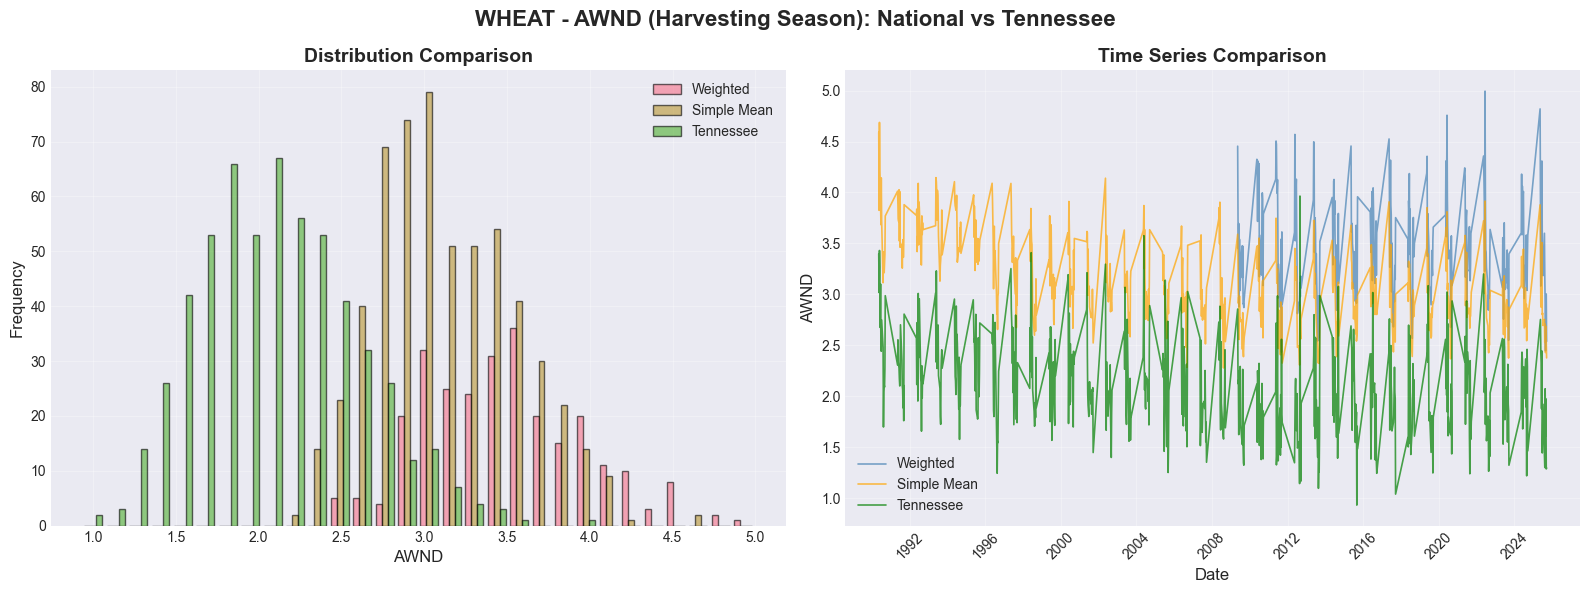

In [17]:
for feature in CLIMATE_FEATURES:
    if feature in df_weighted.columns and feature in df_random_state.columns:
        print(f"\n{'='*80}")
        print(f"Analyzing: {feature} - Harvesting Season (National vs {random_state_name})")
        print(f"{'='*80}")
        plot_random_state_comparison(df_weighted, df_simple_mean, df_random_state, 
                                     feature, CROP, random_state_name, season='harvesting')

## Summary Statistics

In [18]:
def get_summary_stats(df, label, season='planting'):
    season_col = 'is_planting_week' if season == 'planting' else 'is_harvesting_week'
    df_season = df[df[season_col] == 1]
    
    stats = []
    for feature in CLIMATE_FEATURES:
        if feature in df_season.columns:
            stats.append({
                'Feature': feature,
                'Type': label,
                'Season': season.capitalize(),
                'Mean': df_season[feature].mean(),
                'Std': df_season[feature].std(),
                'Min': df_season[feature].min(),
                'Max': df_season[feature].max(),
                'Count': df_season[feature].notna().sum()
            })
    return pd.DataFrame(stats)

# Generate summaries
summary_list = []
for season in ['planting', 'harvesting']:
    summary_list.append(get_summary_stats(df_weighted, 'Weighted', season))
    summary_list.append(get_summary_stats(df_simple_mean, 'Simple Mean', season))
    summary_list.append(get_summary_stats(df_random_state, f'{random_state_name}', season))

summary_all = pd.concat(summary_list, ignore_index=True)

print("\n" + "="*100)
print(f"SUMMARY STATISTICS: {CROP.upper()}")
print("="*100 + "\n")
print(summary_all.to_string(index=False))


SUMMARY STATISTICS: WHEAT

Feature        Type     Season      Mean      Std       Min       Max  Count
   TMAX    Weighted   Planting 18.209730 5.969890  2.149212 29.420538    374
   TMIN    Weighted   Planting  5.170360 5.193902 -8.664079 15.630517    374
   AWND    Weighted   Planting  3.857457 0.586303  2.434415  5.737357    374
   TMAX Simple Mean   Planting 19.059066 5.161620  5.501238 29.546523    792
   TMIN Simple Mean   Planting  6.430124 4.585451 -4.684964 15.883635    792
   AWND Simple Mean   Planting  3.469561 0.520624  2.285503  5.011504    792
   TMAX   Tennessee   Planting 22.349427 5.220319  6.430895 34.259211    792
   TMIN   Tennessee   Planting  9.242668 5.381181 -5.011522 20.165725    792
   AWND   Tennessee   Planting  2.444640 0.635994  0.934286  4.754762    792
   TMAX    Weighted Harvesting 26.943555 2.832896 18.037464 32.510920    272
   TMIN    Weighted Harvesting 13.458783 2.520042  5.308083 17.627182    272
   AWND    Weighted Harvesting  3.481735 0.47787